In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import wandb
from PIL import Image
import os
import random

In [2]:
!wget https://storage.googleapis.com/wandb_datasets/nature_12K.zip
!unzip nature_12K.zip
!rm nature_12K.zip

--2025-04-18 08:07:17--  https://storage.googleapis.com/wandb_datasets/nature_12K.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.197.207, 74.125.142.207, 172.253.117.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.197.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3816687935 (3.6G) [application/zip]
Saving to: ‘nature_12K.zip’

nature_12K.zip      100%[===================>]   3.55G   252MB/s    in 14s     

2025-04-18 08:07:31 (261 MB/s) - ‘nature_12K.zip’ saved [3816687935/3816687935]

Archive:  nature_12K.zip
   creating: inaturalist_12K/
  inflating: inaturalist_12K/.DS_Store  
   creating: inaturalist_12K/train/
   creating: inaturalist_12K/train/Plantae/
  inflating: inaturalist_12K/train/Plantae/1dfc3916ad58af6ce9af9fc8b36ceedd.jpg  
  inflating: inaturalist_12K/train/Plantae/e49eeff2b27ae74351fdf8ffa3791307.jpg  
  inflating: inaturalist_12K/train/Plantae/519ae1c558dff337bb4084934e31a4a8.jpg  


In [10]:
batch_size = 32
img_height = 124
img_width = 124
train_path='C:\\Users\\Dell\\Desktop\\Courses\\Sem_VIII\\DA6401\\DA6401-Introduction-to-Deep-Learning\\Assignment_2\\inaturalist_12K\\train'

In [3]:
# WandB initialization
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: anshul_2010 (anshul_2010-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [11]:
# Hyperparameters for sweep
sweep_config = {
    'method': 'bayes',
    'metric': {
      'name': 'model_accuracy',
      'goal': 'maximize'   
    },
    'parameters': {
        'epoch': {
            'values': [50]
        },
        'dropout':{
            'values': [0.1, 0.2, 0.3]
        },
        'number_of_filters': {
            'values': [32]
        },
        'filter_organisation': {
            'values': [2]
        },
        'size_filter':{
            'values': [3]
        },
        'data_augmentation': {
            'values':['Yes']
        },
        'batch_normalization': {
            'values':['Yes', 'No']
        },
        'learning_rate':{
            'values': [0.001, 0.01, 0.0001]
        },
        'optimizer_fn':{
            'values': ['adam', 'sgd', 'momentum']
        },
        'activation_fn':{
            'values': ['relu', 'tanh']
        },
        'dense':{
            'values': [128, 256, 512]
        },
        'stride':{
            'values': [2]
        }
    }
}

In [12]:
# Data Preparation with PyTorch DataLoader
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_valid = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(root=train_path, transform=transform_train)
valid_dataset = datasets.ImageFolder(root=train_path, transform=transform_valid)

train_size = int(0.8 * len(train_dataset))
valid_size = len(train_dataset) - train_size
train_subset, valid_subset = random_split(train_dataset, [train_size, valid_size])

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_subset, batch_size=batch_size, shuffle=False)

In [13]:
# Define the CNN Model in PyTorch
class CNN_Model(nn.Module):
    def __init__(self, num_filters, filter_organisation, size_filter, dropout, activation_fn, dense_units, stride, batch_normalization):
        super(CNN_Model, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, 
                               out_channels=num_filters, 
                               kernel_size=size_filter, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(num_filters) if batch_normalization == 'Yes' else nn.Identity()
        self.conv2 = nn.Conv2d(in_channels=num_filters, 
                               out_channels=num_filters * filter_organisation, 
                               kernel_size=size_filter, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(num_filters * filter_organisation) if batch_normalization == 'Yes' else nn.Identity()
        self.conv3 = nn.Conv2d(in_channels=num_filters * filter_organisation, 
                               out_channels=num_filters * filter_organisation * filter_organisation, 
                               kernel_size=size_filter, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(num_filters * filter_organisation * filter_organisation) if batch_normalization == 'Yes' else nn.Identity()
        self.conv4 = nn.Conv2d(in_channels=num_filters * filter_organisation * filter_organisation, 
                               out_channels=num_filters * filter_organisation * filter_organisation, 
                               kernel_size=size_filter, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(num_filters * filter_organisation * filter_organisation) if batch_normalization == 'Yes' else nn.Identity()
        self.conv5 = nn.Conv2d(in_channels=num_filters * filter_organisation * filter_organisation, 
                               out_channels=num_filters * filter_organisation * filter_organisation, 
                               kernel_size=size_filter, stride=stride, padding=1)
        self.bn5 = nn.BatchNorm2d(num_filters * filter_organisation * filter_organisation) if batch_normalization == 'Yes' else nn.Identity()
        
        self.fc1 = nn.Linear(num_filters * filter_organisation * filter_organisation * 4, dense_units)
        self.fc2 = nn.Linear(dense_units, 10)
        
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation_fn == 'relu' else torch.tanh
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.activation(x)
        x = F.max_pool2d(x, 2)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.activation(x)
        x = F.max_pool2d(x, 2)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.activation(x)
        x = F.max_pool2d(x, 2)
        
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.activation(x)
        x = F.max_pool2d(x, 2)
        
        x = self.conv5(x)
        x = self.bn5(x)
        x = self.activation(x)
        x = F.max_pool2d(x, 2)
        
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return F.log_softmax(x, dim=1)

In [14]:
def train_model(epoch, dropout, number_of_filters, filter_organisation, size_filter, data_augmentation, batch_normalization, learning_rate, optimizer_fn, activation_fn, dense, stride):
    # Model setup
    model = CNN_Model(
        num_filters=number_of_filters,
        filter_organisation=filter_organisation,
        size_filter=size_filter,
        dropout=dropout,
        activation_fn=activation_fn,
        dense_units=dense,
        stride=stride,
        batch_normalization=batch_normalization
    )
    
    # Set up optimizer
    if optimizer_fn == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_fn == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.0)
    elif optimizer_fn == 'momentum':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    # Training loop
    model.train()
    for epoch in range(epoch):
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_accuracy = 100 * correct / total
        print(f"Epoch [{epoch+1}/{epoch}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {train_accuracy:.2f}%")
        
        wandb.log({
            'accuracy': train_accuracy,
            'loss': running_loss / len(train_loader)
        })
    
    wandb.log({'model_accuracy': train_accuracy})

    return model

In [15]:
class_names = train_dataset.classes
print(class_names)

['Amphibia', 'Animalia', 'Arachnida', 'Aves', 'Fungi', 'Insecta', 'Mammalia', 'Mollusca', 'Plantae', 'Reptilia']


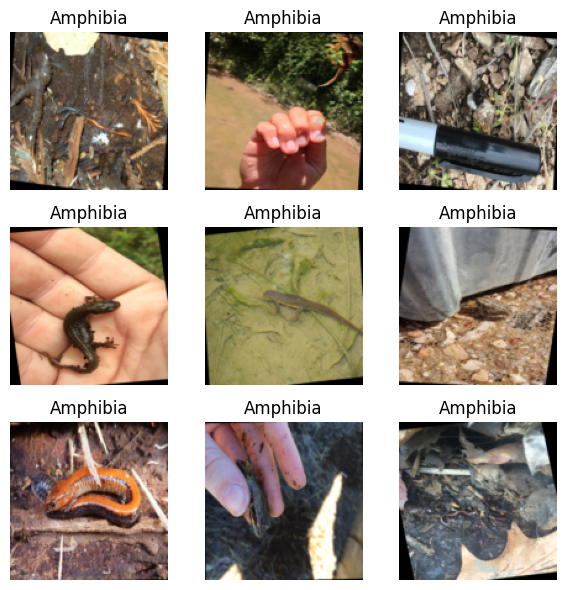

In [16]:
# Access class names
class_names = train_dataset.classes

# Plot first 9 images
plt.figure(figsize=(6, 6))
for i in range(9):
    image, label = train_dataset[i]  # get image and label from Subset
    image = image.permute(1, 2, 0)  # [C, H, W] -> [H, W, C]
    
    # Unnormalize (ImageNet stats)
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    image = image * std + mean
    image = image.clamp(0, 1)

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [17]:
# Data Preparation with PyTorch DataLoader
test_path='C:\\Users\\Dell\\Desktop\\Courses\\Sem_VIII\\DA6401\\DA6401-Introduction-to-Deep-Learning\\Assignment_2\\inaturalist_12K\\val'
transform_valid = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_dataset = datasets.ImageFolder(root=test_path, transform=transform_valid)
xtra_dataset = datasets.ImageFolder(root=test_path, transform=transform_valid)

test_size = int(len(test_dataset))
xtra_size = len(test_dataset) - test_size
test_subset, xtra_subset = random_split(test_dataset, [test_size, xtra_size])

test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)
xtra_loader = DataLoader(xtra_subset, batch_size=batch_size, shuffle=False)

In [19]:
best_params = {
        'epoch': 50,
        'dropout': 0.3,
        'number_of_filters': 32,
        'filter_organisation': 2,
        'size_filter': 3,
        'data_augmentation': 'Yes',
        'batch_normalization': 'Yes',
        'learning_rate': 0.001,
        'optimiser_fn': 'adam',
        'activation_fn': 'relu',
        'dense': 256,
        'stride': 2    
    }

In [21]:
best_model = CNN_Model(
        num_filters=best_params["number_of_filters"],
        filter_organisation=best_params["filter_organisation"],
        size_filter=best_params["size_filter"],
        dropout=best_params["dropout"],
        activation_fn=best_params["activation_fn"],
        dense_units=best_params["dense"],
        stride=best_params["stride"],
        batch_normalization=best_params["batch_normalization"]
    )

In [ ]:
# Set up optimizer
if best_params["optimiser_fn"] == 'adam':
    optimizer = optim.Adam(best_model.parameters(), lr=best_params["learning_rate"])
elif best_params["optimiser_fn"] == 'sgd':
    optimizer = optim.SGD(best_model.parameters(), lr=best_params["learning_rate"], momentum=0.0)
elif best_params["optimiser_fn"] == 'momentum':
    optimizer = optim.SGD(best_model.parameters(), lr=best_params["learning_rate"], momentum=0.9)

# Loss function
criterion = nn.CrossEntropyLoss()

# Training loop
best_model.train()
for epoch in range(best_params["epoch"]):
    running_loss = 0.0
    running_val_loss = 0.0
    correct = 0
    correct_val = 0
    total = 0
    total_val = 0
    # Training phase
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = best_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_accuracy = 100 * correct / total
    
    # Validation phase
    best_model.eval()
    with torch.no_grad():
        for inputs, labels in valid_loader:
            outputs = best_model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    val_accuracy = 100 * correct_val / total_val
    
    print(f"Epoch [{epoch+1}/{epoch}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {train_accuracy:.2f}%", 
          f"Validation Loss: {running_val_loss/len(valid_loader):.4f}, Validation Accuracy: {val_accuracy:.2f}%")

In [25]:
def predict(best_model, test_dir, class_names, img_height=224, img_width=224, device='cuda' if torch.cuda.is_available() else 'cpu'):
    # Set the model to evaluation mode
    best_model.eval()
    best_model.to(device)

    # Define the transform for preprocessing images
    preprocess = transforms.Compose([
        transforms.Resize((img_height, img_width)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet means
                             std=[0.229, 0.224, 0.225])   # ImageNet stds
    ])

    plt.figure(figsize=(25, 25))
    id = 0

    for subdir in os.listdir(test_dir):
        files = [random.choice(os.listdir(os.path.join(test_dir, subdir))) for _ in range(3)]
        index = 1

        for file in files:
            path = os.path.join(test_dir, subdir, file)

            # Load and preprocess the image
            image = Image.open(path).convert('RGB')
            input_tensor = preprocess(image).unsqueeze(0).to(device)  # Add batch dimension

            # Make prediction
            with torch.no_grad():
                output = best_model(input_tensor)
                probabilities = torch.nn.functional.softmax(output[0], dim=0)

            predicted_class = class_names[probabilities.argmax().item()]
            confidence = probabilities.max().item()

            # Plot
            plt.subplot(10, 10, id * 10 + index)
            plt.imshow(image)
            plt.title(f"{predicted_class}, {confidence * 100:.2f}%")
            plt.axis('off')

            index += 1
        id += 1

    plt.tight_layout()
    plt.show()


Predicted class: Animalia, Confidence: 22.55%


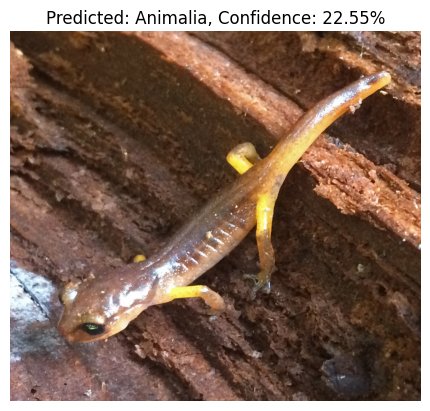

In [26]:
test_path = 'C:\\Users\\Dell\\Desktop\\Courses\\Sem_VIII\\DA6401\\DA6401-Introduction-to-Deep-Learning\\Assignment_2\\inaturalist_12K\\val'
# Predict on test set
for i in range(1):
    # Randomly select a class
    random_class = random.choice(os.listdir(test_path))
    # Randomly select an image from that class
    random_image = random.choice(os.listdir(os.path.join(test_path, random_class)))
    # Construct the full path to the image
    image_path = os.path.join(test_path, random_class, random_image)
    # Load the image
    image = Image.open(image_path).convert('RGB')
    # Preprocess the image
    input_tensor = transform_valid(image).unsqueeze(0)  # Add batch dimension
    # Move the tensor to the same device as the model
    input_tensor = input_tensor.to('cuda' if torch.cuda.is_available() else 'cpu')
    # Make prediction
    with torch.no_grad():
        output = best_model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
    # Get the predicted class and confidence
    predicted_class = class_names[probabilities.argmax().item()]
    confidence = probabilities.max().item()
    # Print the result
    print(f"Predicted class: {predicted_class}, Confidence: {confidence * 100:.2f}%")
    # Display the image
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}, Confidence: {confidence * 100:.2f}%")
    plt.axis('off')
    plt.show()

Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 34s 99ms/step - accuracy: 0.1630 - loss: 2.9354 - val_accuracy: 0.1161 - val_loss: 2.8553
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 87ms/step - accuracy: 0.2597 - loss: 2.3009 - val_accuracy: 0.2322 - val_loss: 2.3235
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 85ms/step - accuracy: 0.3145 - loss: 2.0072 - val_accuracy: 0.2533 - val_loss: 2.3319
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.3822 - loss: 1.8237 - val_accuracy: 0.2553 - val_loss: 2.2207
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 85ms/step - accuracy: 0.4300 - loss: 1.6444 - val_accuracy: 0.2753 - val_loss: 2.1597
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 85ms/step - accuracy: 0.4869 - loss: 1.4941 - val_accuracy: 0.2893 - val_loss: 2.1874
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 85ms/step - accuracy: 0.5338 - loss: 1.3741 - val_accuracy: 0.2923 - val_loss: 2.2348
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 85ms/step - accuracy: 0.5781 - loss: 1.2555 - 

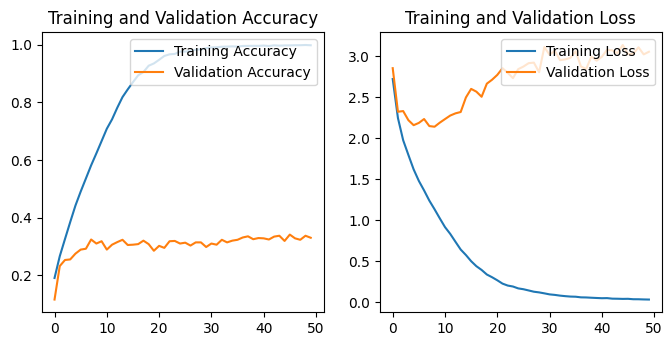

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3504 - loss: 2.8972


In [36]:
model = best_model()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━

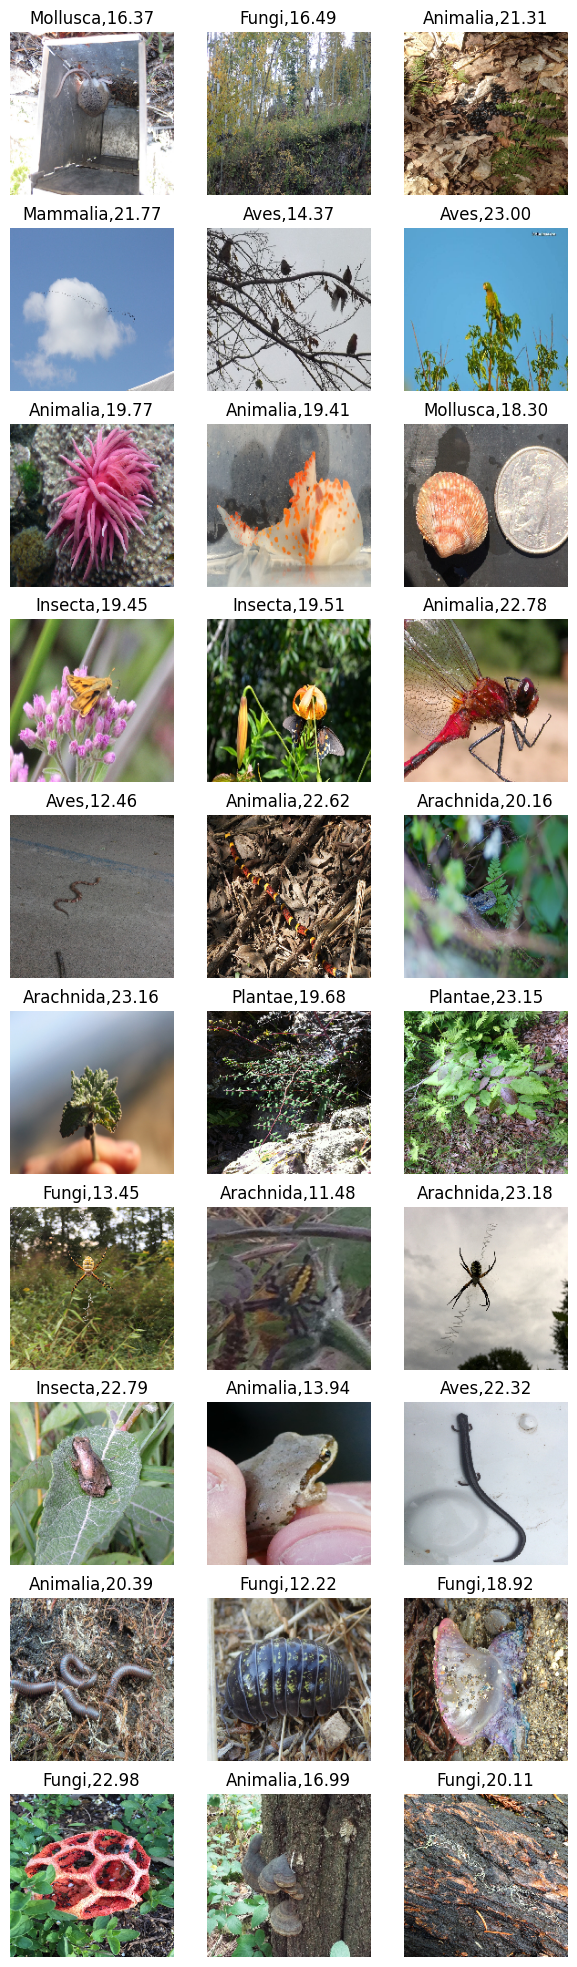

In [38]:
predict(model)